# Homework Starter — Stage 10a: Linear Regression

Use this as a scaffold if your project data isn’t ready. Replace the synthetic data section with your dataset when possible.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install scipy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install scikit-learn

In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import scipy.stats as st

sns.set()
np.random.seed(7)

## 1) Synthetic data (replace with your project data when ready)
- Finance-flavored factors and asset excess return
- Includes a quadratic effect to motivate specification checks

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid')
np.random.seed(7)

# 使用 Starter 的金融模拟数据（若有自己的清洗后数据可直接替换）
n = 200
dates = pd.bdate_range(start="2024-02-01", periods=n)
mkt_excess = np.random.normal(0, 0.011, size=n)
size = np.random.normal(0, 0.008, size=n)
value = np.random.normal(0, 0.009, size=n)
momentum = np.random.normal(0, 0.006, size=n)

beta0, beta_mkt, beta_size, beta_value, beta_mom, beta_mom2 = 0.0001, 0.9, 0.25, -0.15, 0.35, 3.5
noise_scale = 0.0035 + 0.5 * np.abs(mkt_excess)
eps = np.random.normal(0, noise_scale)
asset_excess = (
    beta0 + beta_mkt*mkt_excess + beta_size*size + beta_value*value + beta_mom*momentum
    + beta_mom2*(momentum**2) + eps
)

df = pd.DataFrame({
    'date': dates,
    'mkt_excess': mkt_excess,
    'size': size,
    'value': value,
    'momentum': momentum,
    'asset_excess': asset_excess
})

## 2) Baseline model fit
Follow the steps; replace `df` with your project DataFrame when ready.

In [4]:
X = df[['mkt_excess', 'size', 'value', 'momentum']]
y = df['asset_excess']

# 时间序列数据推荐不洗牌拆分 (shuffle=False)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Baseline R² = {r2:.4f}, RMSE = {rmse:.6f}")

Baseline R² = 0.3677, RMSE = 0.008470


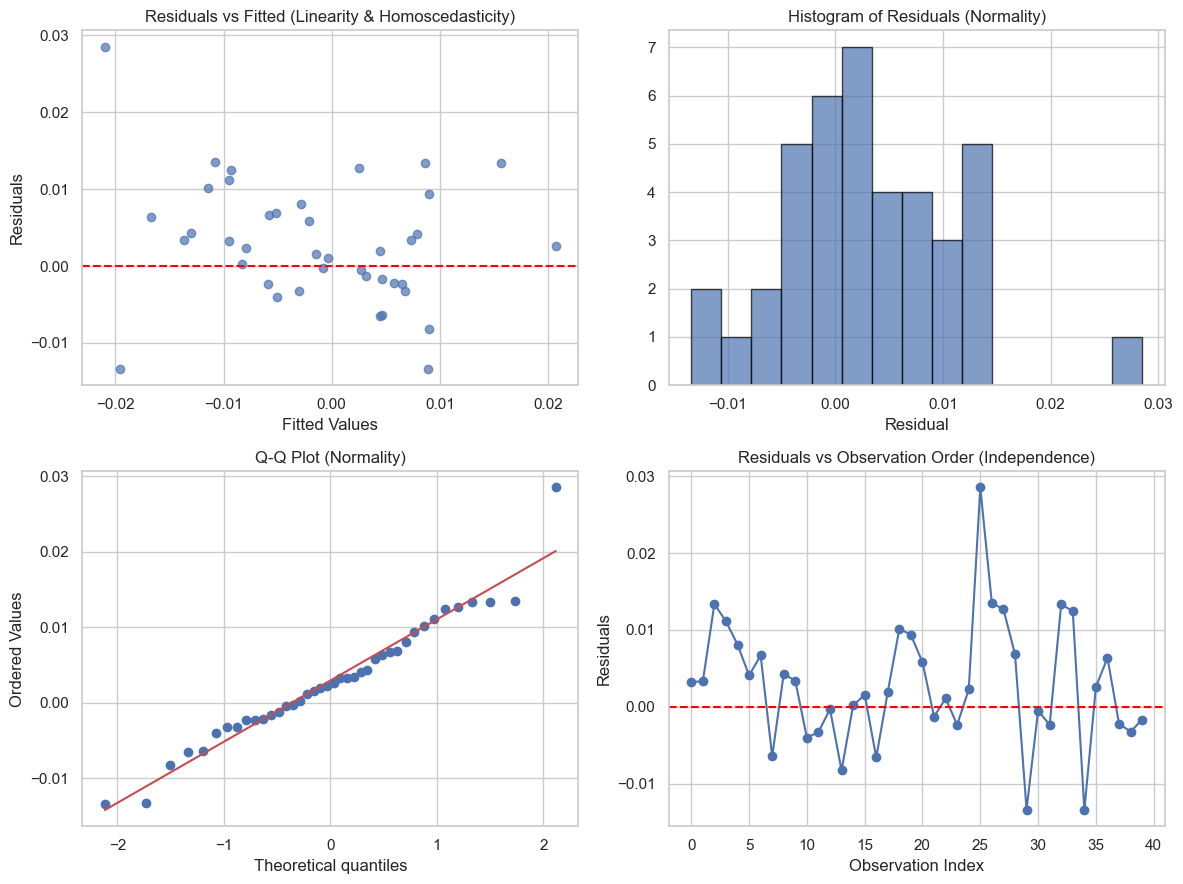

In [5]:
resid = y_test - y_pred
fitted = y_pred

fig, axs = plt.subplots(2, 2, figsize=(12, 9))

# 1. Residuals vs Fitted (线性 & 同方差检验)
axs[0, 0].scatter(fitted, resid, alpha=0.7)
axs[0, 0].axhline(0, color='red', linestyle='--')
axs[0, 0].set_title('Residuals vs Fitted (Linearity & Homoscedasticity)')
axs[0, 0].set_xlabel('Fitted Values')
axs[0, 0].set_ylabel('Residuals')

# 2. Residual Histogram (正态性检验)
axs[0, 1].hist(resid, bins=15, edgecolor='black', alpha=0.7)
axs[0, 1].set_title('Histogram of Residuals (Normality)')
axs[0, 1].set_xlabel('Residual')

# 3. Q-Q Plot (正态性检验)
st.probplot(resid, dist="norm", plot=axs[1, 0])
axs[1, 0].set_title('Q-Q Plot (Normality)')

# 4. Residuals vs Observation Order (独立性检验)
axs[1, 1].plot(np.arange(len(resid)), resid, marker='o', linestyle='-')
axs[1, 1].axhline(0, color='red', linestyle='--')
axs[1, 1].set_title('Residuals vs Observation Order (Independence)')
axs[1, 1].set_xlabel('Observation Index')
axs[1, 1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

## 3) Optional: Add a transformed feature
Add a polynomial or interaction if diagnostics suggest mis-specification.

Transformed Model R² = 0.3681, RMSE = 0.008467


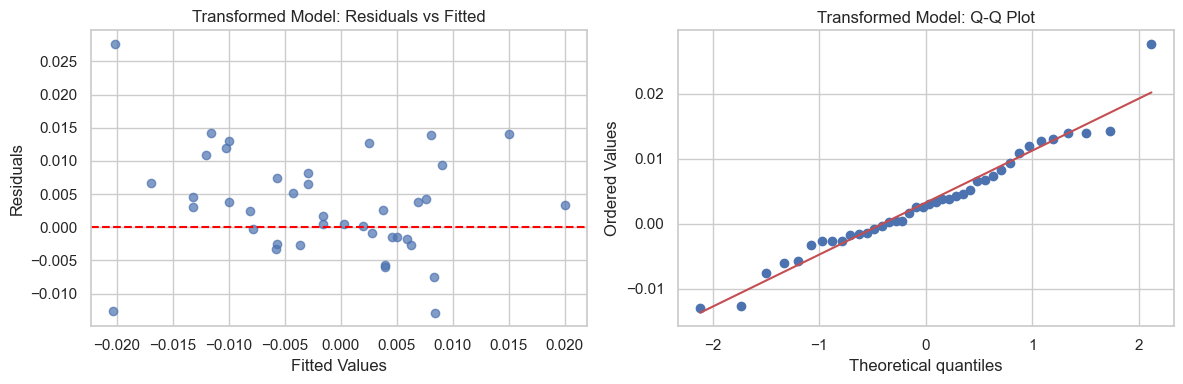

In [6]:
# 增加二次项特征以修正非线性关系
df['momentum_sq'] = df['momentum'] ** 2

X2 = df[['mkt_excess', 'size', 'value', 'momentum', 'momentum_sq']]
X2_train, X2_test = X2.iloc[:len(X_train)], X2.iloc[len(X_train):]

lr2 = LinearRegression().fit(X2_train, y_train)
y_pred2 = lr2.predict(X2_test)

r2_2 = r2_score(y_test, y_pred2)
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred2))
print(f"Transformed Model R² = {r2_2:.4f}, RMSE = {rmse_2:.6f}")

resid2 = y_test - y_pred2
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].scatter(y_pred2, resid2, alpha=0.7)
axs[0].axhline(0, color='red', linestyle='--')
axs[0].set_title('Transformed Model: Residuals vs Fitted')
axs[0].set_xlabel('Fitted Values')
axs[0].set_ylabel('Residuals')
st.probplot(resid2, dist='norm', plot=axs[1])
axs[1].set_title('Transformed Model: Q-Q Plot')
plt.tight_layout()
plt.show()

## 4) Interpretation and conclusion
The following discussion evaluates the four regression assumptions, connects the test metrics to practical usefulness, and distinguishes explanatory interpretation from predictive performance.

### Model Diagnostics & Assumption Checks

1. **Linearity**: 
   - The baseline residuals are distributed around zero, although the residual-versus-fitted plot shows some structure rather than a perfectly random cloud. This suggests that the linear specification is a reasonable baseline but may omit nonlinear relationships. The transformed-model plot provides a direct visual comparison; it does not show a dramatic improvement.

2. **Homoscedasticity**: 
   - The residual spread changes somewhat across fitted values, suggesting mild heteroscedasticity. This is consistent with the way the synthetic noise scale increases with the absolute market excess return, so constant error variance should be treated cautiously.

3. **Normality**: 
   - The histogram is broadly bell-shaped and most Q-Q points lie near the reference line, with some tail deviations. There is no severe visible violation, but the plots do not prove exact normality.

4. **Independence**: 
   - The residual sequence plot shows no obvious sustained trend or repeating pattern. This supports, but does not prove, independence; a formal autocorrelation test or residual ACF would be a useful follow-up for time-ordered financial data.

### Model Trustworthiness & Conclusion

* **Why $x^2$ is still Linear Regression**: 
  - Adding $x^2$ creates a non-linear feature transformation, but the model remains linear in its parameters ($\beta$ coefficients). The mathematical formulation $y = \beta_0 + \beta_1 x + \beta_2 x^2 + \epsilon$ is strictly a linear regression problem.

* **Trust & Metrics Assessment**: 
  - **Trust Level**: Moderate as a baseline, but limited for precise prediction.
  - On the held-out test period, the baseline model has $R^2 = 0.3677$ and $RMSE = 0.008470$. Thus, it explains about 36.8% of the test-set variation, while a typical prediction error is about 0.00847 in excess-return units (approximately 0.847 percentage points when returns are expressed as decimals). The transformed model has $R^2 = 0.3681$ and $RMSE = 0.008467$, which is only a negligible improvement. The quadratic term is therefore not justified by a meaningful out-of-sample performance gain in this split.

* **Explanation versus prediction**:
  - For explanation, coefficient signs and magnitudes are useful only if the specification and assumptions are credible; these results describe association and do not establish causality. For prediction, the main evidence is held-out performance. The moderate $R^2$, prediction error, and mild residual issues make this model a useful benchmark rather than a high-confidence forecasting tool.

* **Next Steps**: 
  - Test residual autocorrelation formally, compare against a simple benchmark, and evaluate performance with rolling or time-series cross-validation. If inference is needed, use heteroscedasticity-consistent standard errors; if prediction is the goal, investigate additional economically motivated features and validate them out of sample.